In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

In [ ]:
## 1. Dataset Overview
Here we load the data and take a first look at its structure and types.

In [2]:
train = pd.read_csv("train.csv")
val = pd.read_csv("val.csv")

In [3]:
train.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1385950,1,2016-01-08 22:31:12,1,-73.990646,40.751068,-73.995789,40.728146,N,525
1,id1885523,2,2016-01-02 12:36:39,1,-73.982658,40.745071,-74.003258,40.732971,N,799
2,id0892204,2,2016-02-21 00:24:16,1,-73.999481,40.728580,-74.000252,40.718800,N,374
3,id2463973,2,2016-05-08 15:06:34,1,-73.977058,40.759850,-73.949989,40.776001,N,696
4,id1496105,2,2016-05-06 13:54:36,2,-73.977798,40.758221,-73.993080,40.743130,N,703


In [4]:
train.shape

(5000, 10)

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  5000 non-null   object 
 1   vendor_id           5000 non-null   int64  
 2   pickup_datetime     5000 non-null   object 
 3   passenger_count     5000 non-null   int64  
 4   pickup_longitude    5000 non-null   float64
 5   pickup_latitude     5000 non-null   float64
 6   dropoff_longitude   5000 non-null   float64
 7   dropoff_latitude    5000 non-null   float64
 8   store_and_fwd_flag  5000 non-null   object 
 9   trip_duration       5000 non-null   int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 390.8+ KB


In [6]:
train.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,5000.00000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,1.52000,1.65440,-73.973659,40.751530,-73.972305,40.752438,969.608200
std,0.49965,1.29325,0.057585,0.042378,0.056861,0.045901,3616.929016
min,1.00000,1.00000,-74.177292,40.619514,-74.183403,40.575306,2.000000
25%,1.00000,1.00000,-73.991638,40.737639,-73.991266,40.735735,392.000000
50%,2.00000,1.00000,-73.981895,40.754238,-73.979771,40.754862,656.000000
75%,2.00000,2.00000,-73.967855,40.768205,-73.962240,40.770319,1066.000000
max,2.00000,6.00000,-70.851616,43.017578,-70.851616,43.017578,86329.000000


In [7]:
train.isna().sum()

id                    0
vendor_id             0
pickup_datetime       0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [8]:
train.trip_duration.describe()

count     5000.000000
mean       969.608200
std       3616.929016
min          2.000000
25%        392.000000
50%        656.000000
75%       1066.000000
max      86329.000000
Name: trip_duration, dtype: float64

<Axes: >

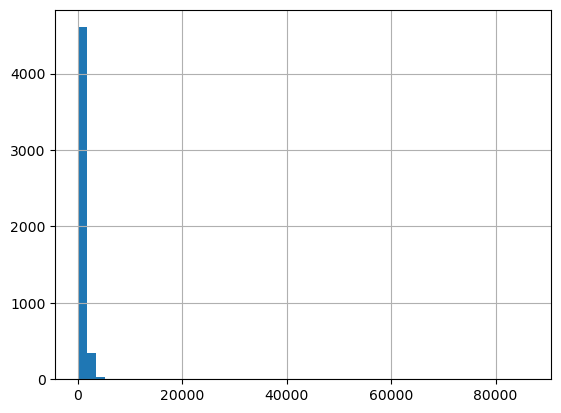

In [9]:
train.trip_duration.hist(bins=50)

The distribution of trip_duration is highly right-skewed.
Most trips are short, while a few trips have extremely large durations (outliers).

To handle this skewness and stabilize variance, we apply log transformation.

In [10]:
train.passenger_count.value_counts()

passenger_count
1    3542
2     734
5     300
3     208
6     137
4      79
Name: count, dtype: int64

In [11]:
train["pickup_datetime"] = pd.to_datetime(train["pickup_datetime"])

In [12]:
train = train[train.trip_duration < 10000]

In [13]:
train = train[train.passenger_count > 0]
train = train[train.passenger_count <= 6]

In [14]:
train = train[train.trip_duration > 10]

In [15]:
train = train[
    (train.pickup_latitude.between(40, 42)) &
    (train.pickup_longitude.between(-75, -72)) &
    (train.dropoff_latitude.between(40, 42)) &
    (train.dropoff_longitude.between(-75, -72))]


In [16]:
train.trip_duration.describe()

count    4979.000000
mean      820.173931
std       630.515531
min        13.000000
25%       393.000000
50%       656.000000
75%      1062.000000
max      7489.000000
Name: trip_duration, dtype: float64

In [ ]:
## 2. Target Variable Analysis
`trip_duration` is heavily right-skewed. We apply log1p to normalize it.
**Conclusion:** Log-transformed target will be used in modeling.

In [17]:
for df in [train, val]:
    df["log_trip_duration"] = np.log1p(df["trip_duration"])

<Axes: >

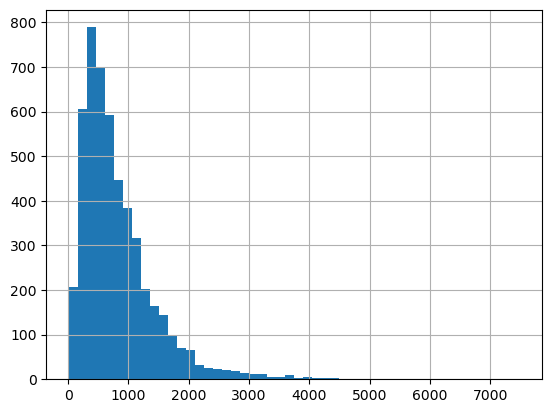

In [18]:
train.trip_duration.hist(bins=50)

After applying log transformation, the distribution becomes more symmetric and closer to normal.

This transformation helps linear models perform better and reduces the impact of outliers.

<Axes: >

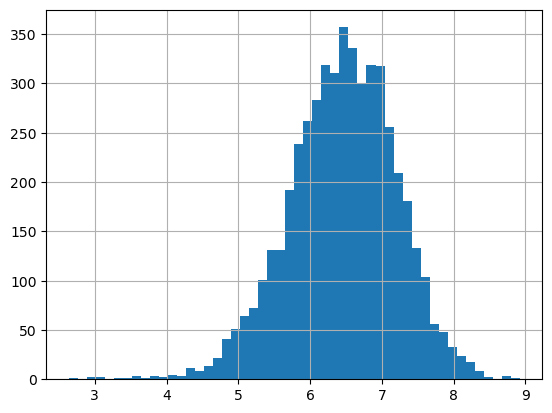

In [19]:
train["log_trip_duration"].hist(bins=50)